In [94]:
import random

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [153]:
# Read in and merge data
disc_data = pd.read_csv('../02_processed_data/cleaned_csv_data.csv')

In [161]:
disc_data[disc_data['participantId']==disc_data['participantId'].unique()[0]]
ul = disc_data[disc_data['taskLabel'].str.startswith("$10 ")]
ur = disc_data[disc_data['taskLabel'].str.startswith("$100 ")]
ll = disc_data[disc_data['taskLabel'].split(" ")[0].str.endswith("10")]
lr = disc_data[disc_data['taskLabel'].split(" ")[0].str.endswith("100")]

# fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))


AttributeError: 'Series' object has no attribute 'split'

In [155]:
def hyperbolic_model(OA, h, s, amount):
    return amount / (1 + (h * OA**s))

pids = []
tasks = []
hs = []
ss = []
r2 = []
maes = []
rmses = []

for pid in disc_data['participantId'].unique():
    pid_data = disc_data[disc_data['participantId'] == pid]
    for task in pid_data['taskLabel'].unique():
        task_data = pid_data[pid_data['taskLabel'] == task]
        pids.append(pid)
        tasks.append(task)

        odds_against = (1-task_data['probability'])/task_data['probability']
        indifference_point = task_data['indifferencePoint']
        amount = task_data['certainAmount'].iloc[0]*2

        # Define a wrapper to fix 'amount'
        def model_for_fit(OA, h, s):
            return hyperbolic_model(OA, h, s, amount)

        # Fit the model
        popt, pcov = curve_fit(model_for_fit, odds_against, indifference_point, p0=[0.5, 0.5], bounds=(0, 2))
        h, s = popt

        # Save the parameters
        hs.append(h)
        ss.append(s)

        # Calculate R-squared
        predicted = model_for_fit(odds_against, h, s)
        ss_res = np.sum((indifference_point - predicted) ** 2)
        ss_tot = np.sum((indifference_point - np.mean(indifference_point)) ** 2)
        r2.append((ss_res / ss_tot))
        maes.append(np.mean(np.abs(indifference_point - predicted)))
        rmses.append(np.sqrt(np.mean((indifference_point - predicted) ** 2)))
        
fit_data = pd.DataFrame({'pid': pids, 'task': tasks, 'h': hs, 's': ss, 'r2': r2, 'mae': maes, 'rmse': rmses})
fit_data['task_type'] = fit_data['task'].str.split('10').str[0]
fit_data['task_type'] = ["money" if val=="$" else val for val in fit_data['task_type']]
fit_data['r2'] = fit_data['r2'].astype(str)
fit_data['r2'] = fit_data['r2'].replace("inf", np.nan)
fit_data['r2'] = fit_data['r2'].astype(float)
fit_data

/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_10283/2931103162.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  r2.append((ss_res / ss_tot))


,pid,task,h,s,r2,mae,rmse,task_type
0,P426866,$10 Discounting,2.000000e+00,0.433313,0.200226,1.390184,1.590908,money
1,P426866,$100 Discounting,2.000000e+00,0.846096,0.016763,4.130643,4.560346,money
2,P426866,steak10 Discounting,4.869067e-01,0.316326,0.073381,0.419433,0.506788,steak
3,P426866,steak100 Discounting,2.000000e+00,0.557039,0.057405,7.094482,8.127777,steak
4,P917583,pasta100 Discounting,2.000000e+00,0.406117,21.037130,25.310581,36.260456,pasta
5,P917583,$100 Discounting,2.000000e+00,0.406117,6.294280,22.185581,29.751187,money
6,P917583,pasta10 Discounting,1.405917e+00,0.344951,0.030949,0.421440,0.481787,pasta
7,P917583,$10 Discounting,1.138476e+00,0.234382,5.654967,1.494897,2.378017,money
8,P441043,$100 Discounting,2.491516e-14,0.002948,3.942935,53.437500,61.853690,money
9,P441043,$10 Discounting,2.298825e-01,0.696494,0.077292,0.428848,0.569971,money


R-squared: 0.4672


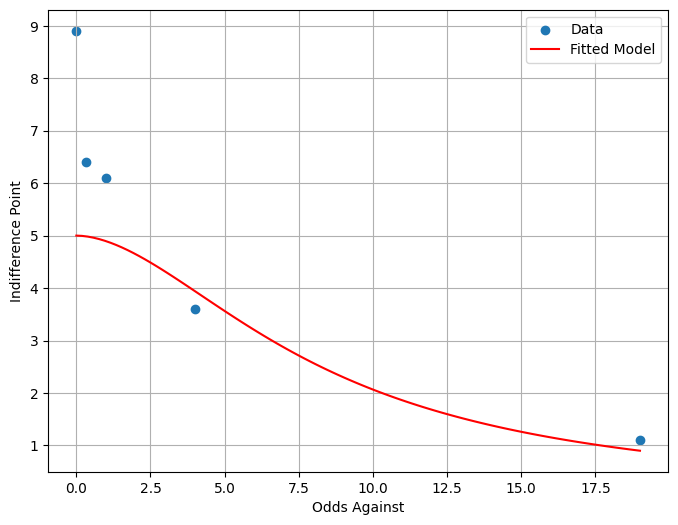

In [108]:
# # Prepare your data
# disc_df = all_data[all_data['eventType']=='discountingTrial'].reset_index(drop=True)
# disc_df = disc_df[['participantId', 'certainAmount', 'taskLabel', 'probability', 'indifferencePoint']]
# disc_df['odds_against'] = (1-disc_df['probability'])/disc_df['probability']
# disc_df = disc_df.drop_duplicates(subset=['participantId', 'certainAmount', 'taskLabel', 'probability', 'indifferencePoint'])

# # Select a participant and amount for fitting
# fit_data = disc_df[(disc_df['participantId']==random.choice(disc_df['participantId'].unique())) & (disc_df['certainAmount'].isin([5.0,50.0]))]

# # Use the amount as a fixed value (assuming all are the same in fit_data)
# amount = fit_data['certainAmount'].iloc[0]

# # Define a wrapper for curve_fit with amount fixed
# def model_for_fit(OA, h, s):
#     return hyperbolic_model(OA, h, s, amount)

# # Fit the model
# popt, pcov = curve_fit(model_for_fit, fit_data['odds_against'], fit_data['indifferencePoint'], bounds=(0, 2))
# h, s = popt

# # Calculate R-squared
# predicted = model_for_fit(fit_data['odds_against'], h, s)
# ss_res = np.sum((fit_data['indifferencePoint'] - predicted) ** 2)
# ss_tot = np.sum((fit_data['indifferencePoint'] - np.mean(fit_data['indifferencePoint'])) ** 2)
# r_squared = 1 - (ss_res / ss_tot)
# print(f"R-squared: {r_squared:.4f}")

# # Plot the results
# plt.figure(figsize=(8, 6))
# plt.scatter(fit_data['odds_against'], fit_data['indifferencePoint'], label='Data')
# x_fit = np.linspace(min(fit_data['odds_against']), max(fit_data['odds_against']), 100)
# plt.plot(x_fit, model_for_fit(x_fit, h, s), 'r-', label='Fitted Model')
# plt.xlabel('Odds Against')
# plt.ylabel('Indifference Point')
# plt.legend()
# plt.grid(True)
# plt.show()

In [124]:
def hyperbolic_model(amount, OA, h, s):
    """Probability hyperbolic discounting model"""
    return amount / (1 + (h * OA))**s

disc_df = all_data[all_data['eventType']=='discountingTrial'].reset_index(drop=True)
disc_df = disc_df[['participantId', 'certainAmount', 'taskLabel', 'probability', 'indifferencePoint']]
disc_df['odds_against'] = (1-disc_df['probability'])/disc_df['probability']
# disc_df = disc_df.drop_duplicates(subset=['participantId', 'certainAmount', 'taskLabel', 'probability', 'indifferencePoint'])
fit_data = disc_df[(disc_df['participantId']==random.choice(disc_df['participantId'].unique()))]# & (disc_df['certainAmount'].isin([5.0,50.0]))]
fit_data['certainAmount'] = fit_data['certainAmount']*2
fit_data
# popt, pcov = curve_fit(hyperbolic_model, fit_data['odds_against'], fit_data['indifferencePoint'], bounds=(0, 2))
# h = popt[0]  # discounting parameter
# # s = popt[1]  # sensitivity parameter

# # Calculate R-squared
# predicted = hyperbolic_model(fit_data['certainAmount'], fit_data['odds_against'], h, s)
# ss_res = np.sum((fit_data['indifferencePoint'] - predicted) ** 2)
# ss_tot = np.sum((fit_data['indifferencePoint'] - np.mean(fit_data['indifferencePoint'])) ** 2)
# r_squared = 1 - (ss_res / ss_tot)
# print(f"R-squared: {r_squared:.4f}")

# # Plot the results
# plt.figure(figsize=(8, 6))
# plt.scatter(fit_data['odds_against'], fit_data['indifferencePoint'], label='Data')
# x_fit = np.linspace(min(fit_data['odds_against']), max(fit_data['odds_against']), 100)
# plt.plot(x_fit, hyperbolic_model(fit_data['certainAmount'].iloc[0], x_fit, h, s), 'r-', label='Fitted Model')
# plt.xlabel('Odds Against')
# plt.ylabel('Indifference Point')
# plt.legend()
# plt.grid(True)
# plt.show()

/var/folders/c5/vpx80swj4yb9ytlnrk8w2qnr0000gn/T/ipykernel_10283/1593970878.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fit_data['certainAmount'] = fit_data['certainAmount']*2


,participantId,certainAmount,taskLabel,probability,indifferencePoint,odds_against
60,P9708,100.0,$100 Discounting,0.05,10.9375,19.000000
61,P9708,100.0,$100 Discounting,0.20,14.0625,4.000000
62,P9708,100.0,$100 Discounting,0.50,39.0625,1.000000
63,P9708,100.0,$100 Discounting,0.75,64.0625,0.333333
64,P9708,100.0,$100 Discounting,1.00,89.0625,0.000000


In [129]:
all_data[all_data['participantId']==all_data['participantId'].unique()[0]]

,participantId,prolificId,eventType,questionId,question,optionA,optionB,choice,taskLabel,probability,certainAmount,trialIndex,indifferencePoint
0,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,12.0,Which would you prefer?,30% Chance of $66,100% Chance of $20,B,money,0.30,20.0,NaN,NaN
1,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,7.0,Which would you prefer?,85% Chance of $66,100% Chance of $56,A,money,0.85,56.0,NaN,NaN
2,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,6.0,Which would you prefer?,30% Chance of $33,100% Chance of $10,B,money,0.30,10.0,NaN,NaN
3,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,17.0,Which would you prefer?,60% Chance of $33 worth of steak,100% Chance of $10 worth of steak,A,steak,0.60,10.0,NaN,NaN
4,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,5.0,Which would you prefer?,60% Chance of $33,100% Chance of $10,B,money,0.60,10.0,NaN,NaN
5,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,4.0,Which would you prefer?,85% Chance of $33,100% Chance of $10,B,money,0.85,10.0,NaN,NaN
6,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,9.0,Which would you prefer?,30% Chance of $66,100% Chance of $56,B,money,0.30,56.0,NaN,NaN
7,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,14.0,Which would you prefer?,60% Chance of $33 worth of steak,100% Chance of $28 worth of steak,B,steak,0.60,28.0,NaN,NaN
8,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,16.0,Which would you prefer?,85% Chance of $33 worth of steak,100% Chance of $10 worth of steak,A,steak,0.85,10.0,NaN,NaN
9,P426866,Iw3CNnBi7w55a8ZZN5Pkiu1v,fixedChoice,15.0,Which would you prefer?,30% Chance of $33 worth of steak,100% Chance of $28 worth of steak,B,steak,0.30,28.0,NaN,NaN
